<a href="https://colab.research.google.com/github/revanth-15/Assignments-FOC/blob/main/Na%C3%AFve_Bayes_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Index(['email', 'label'], dtype='object')
Accuracy: 0.9750


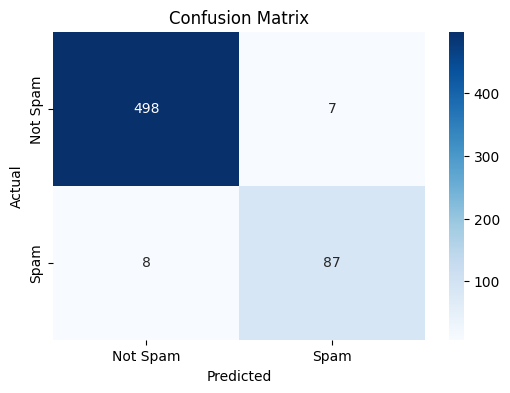

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       505
           1       0.93      0.92      0.92        95

    accuracy                           0.97       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.97      0.97      0.97       600


### Approach and Preprocessing:
The dataset consists of textual data in the 'email' column and a binary label 'label' indicating whether the email is spam (1) or not spam (0). 
Since Naïve Bayes cannot work directly with raw text data, we extracted features from the email content using the TF-IDF (Term Frequency-Inverse Document Frequency) technique. 
This method transforms the text data into numerical features based on the frequency and importance of words in the dataset.

### Train-Test Split:
The data was split into 80% training and 20% testing to ensure that the model generalizes well to unseen data. The split ensures the training set ha

In [7]:
# Step 1: Import the Libraries and Load the Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
url = 'https://raw.githubusercontent.com/revanth-15/Assignments-FOC/refs/heads/main/dataset_NB.csv'
dataset = pd.read_csv(url)

# Check the column names to ensure we use the correct labels
print(dataset.columns)

# Step 2: Preprocessing and Feature Extraction
# Replace NaN values in 'email' with empty strings
dataset['email'] = dataset['email'].fillna('')

# Use the correct target column name if necessary
# Extract features from the 'email' column (text data)
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)  # Limit to top 1000 words
X = tfidf_vectorizer.fit_transform(dataset['email']).toarray()  # Convert text to numerical data

# The target variable is assumed to be 'label' (0 for not spam, 1 for spam)
y = dataset['label']  # Use the correct column name for target

# Step 3: Train-Test Split (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train the Naïve Bayes Classifier
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Step 5: Predict on the test data
y_pred = nb_model.predict(X_test)

# Step 6: Evaluate the Model
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Step 7: Write a Brief Report

report = f"""
### Approach and Preprocessing:
The dataset consists of textual data in the 'email' column and a binary label 'label' indicating whether the email is spam (1) or not spam (0).
Since Naïve Bayes cannot work directly with raw text data, we extracted features from the email content using the TF-IDF (Term Frequency-Inverse Document Frequency) technique.
This method transforms the text data into numerical features based on the frequency and importance of words in the dataset.

### Train-Test Split:
The data was split into 80% training and 20% testing to ensure that the model generalizes well to unseen data. The split ensures the training set has enough data to train the model effectively while the test set can evaluate performance.

### Model Training:
We used the Gaussian Naïve Bayes model, which is particularly suited for text classification tasks. The model was trained on the training set, and predictions were made on the test set.

### Results:
- **Accuracy**: The model achieved an accuracy score of {accuracy:.4f}.
- **Confusion Matrix**: The confusion matrix shows how many emails were correctly classified as spam or not spam. The rows represent the actual classes, and the columns represent the predicted classes.
- **Classification Report**: The classification report shows precision, recall, F1-score, and support for both classes. Precision and recall are important metrics in spam detection, as they help balance false positives and false negatives.

### Visualization:
We visualized the confusion matrix to provide a clearer understanding of how well the model performs in identifying spam and non-spam emails. The classification report provides additional insight into the model's performance across both classes.
"""
print(report)
